# MRI Brain Tumor Dataset: 4-Class From Kaggle
Learn about medical AI

#### Import

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset
import matplotlib.pyplot as plt
import torch.nn.functional as F

#### Load Dataset

In [2]:
TRAIN_DIR = "Training"

IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.RandomAffine(degrees=0, translate=(0.03, 0.03)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_full = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

val_full = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=val_transform
)

class_names = train_full.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Total training folder images:", len(train_full))

Classes: ['Glioma', 'Meningioma', 'No-tumor', 'Pituitary']
Number of classes: 4
Total training folder images: 5712


In [3]:
val_size = int(len(train_full) * 0.15)
train_size = len(train_full) - val_size

generator = torch.Generator().manual_seed(42)
indices = torch.randperm(len(train_full), generator=generator)

train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_dataset = Subset(train_full, train_indices)
val_dataset = Subset(val_full, val_indices)

print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Train images: 4856
Validation images: 856


In [4]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

#### Visualization of Dataset

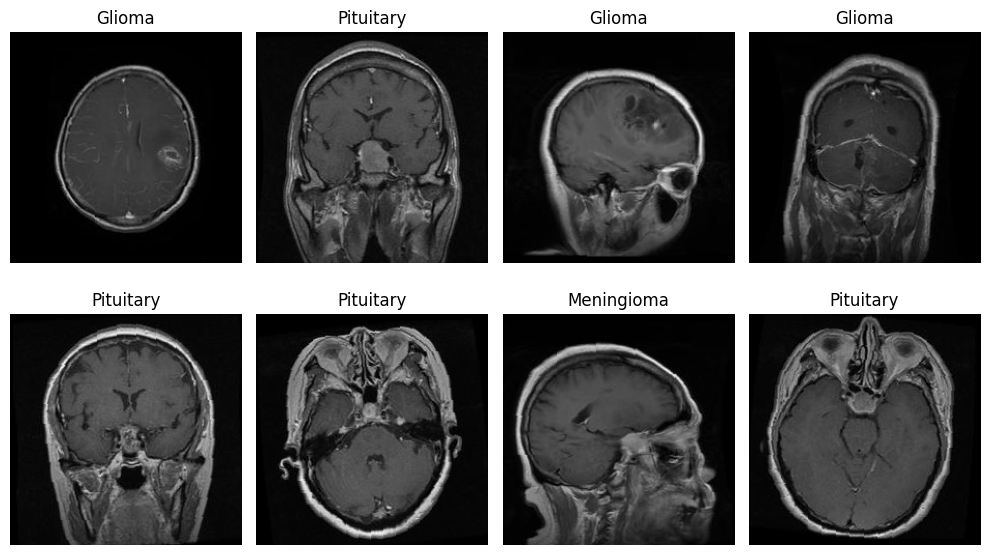

In [5]:
# Visa några bilder från batchen
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 6))

for i in range(8):
    img = images[i].permute(1, 2, 0)

    # undo Normalize ungefärligt för visualisering
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    img = img * std + mean
    img = img.clamp(0, 1)

    label = labels[i].item()

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

### DenseLayer
Regular CNN: 64 Channel --> 16 Channel

Dense: 64ch + 16ch --> 80ch, meaning it keeps all the old features aswell.


In [6]:
class DenseLayer(nn.Module):
    def __init__(self, in_channels, gain):
        super().__init__()

        self.layer = nn.Sequential(
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True), # Save memory with inplace
            nn.Conv2d(in_channels, 4*gain, kernel_size=1, bias=False), # -------------------------------
            
            nn.BatchNorm2d(4*gain),
            nn.ReLU(inplace=True),
            nn.Conv2d(4*gain, gain, kernel_size=3, padding=1, bias=False)
        )
    
    def forward(self, x):
        new_features = self.layer(x)
        return torch.cat([x, new_features], dim=1)

### Transition Layer

In [7]:
class TransitionLayer(nn.Module):
    def __init__(self, in_channels, compression=0.5):
        super().__init__()

        out_channels = int(in_channels * compression)

        self.transition = nn.Sequential(
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1,
                stride=1,
                bias=False
            ),
            nn.AvgPool2d(kernel_size=2, stride=2)
        )

        self.out_channels = out_channels

    def forward(self, x):
        return self.transition(x)

## DenseBlock

In [8]:
class DenseBlock(nn.Module):
    def __init__(self, num_layers, in_channels, growth_rate):
        super().__init__()

        layers = []
        channels = in_channels

        for i in range(num_layers):
            layers.append(DenseLayer(channels, growth_rate))
            channels += growth_rate

        self.block = nn.Sequential(*layers)
        self.out_channels = channels

    def forward(self, x):
        return self.block(x)

# DenseNet

In [9]:
class CustomDenseNet(nn.Module):
    def __init__(
        self,
        num_classes,
        growth_rate=16,
        block_layers=[4, 6, 8],
        init_channels=32,
        compression=0.5
    ):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(
                3,
                init_channels,
                kernel_size=7,
                stride=2,
                padding=3,
                bias=False
            ),
            nn.BatchNorm2d(init_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        channels = init_channels

        self.blocks = nn.ModuleList()
        self.transitions = nn.ModuleList()

        for i, num_layers in enumerate(block_layers):
            dense_block = DenseBlock(
                num_layers=num_layers,
                in_channels=channels,
                growth_rate=growth_rate
            )

            self.blocks.append(dense_block)
            channels = dense_block.out_channels

            if i != len(block_layers) - 1:
                transition = TransitionLayer(
                    in_channels=channels,
                    compression=compression
                )

                self.transitions.append(transition)
                channels = transition.out_channels

        self.final_bn = nn.BatchNorm2d(channels)
        self.classifier = nn.Linear(channels, num_classes)

    def forward(self, x):
        x = self.stem(x)

        for i, block in enumerate(self.blocks):
            x = block(x)

            if i < len(self.transitions):
                x = self.transitions[i](x)

        x = self.final_bn(x)
        x = F.relu(x, inplace=True)

        x = F.adaptive_avg_pool2d(x, (1, 1))
        x = torch.flatten(x, 1)

        x = self.classifier(x)
        return x

## Training

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = CustomDenseNet(
    num_classes=num_classes,
    growth_rate=16,
    block_layers=[4, 6, 8],
    init_channels=32
).to(device)

Using device: cuda


#### Parameters

In [11]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 20
best_val_loss = float("inf")

### Simulation

In [12]:
for epoch in range(epochs):
    model.train()

    train_loss = 0.0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        train_total += labels.size(0)

    train_loss = train_loss / train_total

    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, dim=1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss / val_total
    val_acc = val_correct / val_total

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_custom_densenet.pth")
        print(f"Saved best model with Val Loss: {best_val_loss:.4f}")

Epoch [1/20] Train Loss: 0.6735 Val Loss: 1.1098 Val Acc: 0.5900
Saved best model with Val Loss: 1.1098
Epoch [2/20] Train Loss: 0.5387 Val Loss: 0.7754 Val Acc: 0.6706
Saved best model with Val Loss: 0.7754
Epoch [3/20] Train Loss: 0.4479 Val Loss: 0.6615 Val Acc: 0.7395
Saved best model with Val Loss: 0.6615
Epoch [4/20] Train Loss: 0.4041 Val Loss: 0.4175 Val Acc: 0.8376
Saved best model with Val Loss: 0.4175
Epoch [5/20] Train Loss: 0.3499 Val Loss: 1.5155 Val Acc: 0.6928
Epoch [6/20] Train Loss: 0.3293 Val Loss: 0.7989 Val Acc: 0.7196
Epoch [7/20] Train Loss: 0.3361 Val Loss: 0.2683 Val Acc: 0.9100
Saved best model with Val Loss: 0.2683
Epoch [8/20] Train Loss: 0.2844 Val Loss: 0.2686 Val Acc: 0.9065
Epoch [9/20] Train Loss: 0.2570 Val Loss: 1.4242 Val Acc: 0.6215
Epoch [10/20] Train Loss: 0.2435 Val Loss: 1.9679 Val Acc: 0.4871
Epoch [11/20] Train Loss: 0.2495 Val Loss: 0.3704 Val Acc: 0.8610
Epoch [12/20] Train Loss: 0.2337 Val Loss: 0.9068 Val Acc: 0.7570
Epoch [13/20] Train Lo

### Testing

In [13]:
TEST_DIR = "Testing"

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Test images:", len(test_dataset))
print("Test classes:", test_dataset.classes)

Test images: 1311
Test classes: ['Glioma', 'Meningioma', 'No-tumor', 'Pituitary']


In [ ]:
model.load_state_dict(torch.load("best_custom_densenet.pth", map_location=device))
model.to(device)
model.eval()

test_loss = 0.0
test_correct = 0
test_total = 0

criterion = torch.nn.CrossEntropyLoss()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, dim=1)
        test_correct += (predicted == labels).sum().item()
        test_total += labels.size(0)

test_loss = test_loss / test_total
test_acc = test_correct / test_total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")